# Step 1 — External Documents: Hate-speech terminology & Glossary

Crawls Hate-Speech and Symbol Terminology references online and produces structured text chunks
compatible with the Step 2 chunking pipeline.

- *Output*: documents/adl_symbols.csv
- *Schema*: chunk_id | text  (same as chunks/chunks.csv)
- *Label*: convention: all ADL entries are labeled [hate] since every symbol in the database is hate-associated by definition.

This file feeds into Step 2, Section 5 (External Documents).

In [3]:
import os
import re
import pandas as pd
from urllib.parse import urljoin
from firecrawl import Firecrawl
from pathlib import Path

import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from transformers import AutoTokenizer



ImportError: cannot import name '_is_pandas_dataframe' from 'matplotlib.cbook' (/Users/pierrebernadet/anaconda3/lib/python3.11/site-packages/matplotlib/cbook/__init__.py)

In [ ]:
# PRIVATE API key 
# Replace with your actual API key before running !
import os
os.environ["FIRECRAWL_API_KEY"] = "fc-enter_personal_api_key_here"  

In [ ]:
# --------------------------
# 1. Firecrawl API key setup
# --------------------------

FIRECRAWL_API_KEY = os.environ.get("FIRECRAWL_API_KEY")

if not FIRECRAWL_API_KEY:
    raise ValueError(
        "Missing FIRECRAWL_API_KEY.\n\n"
        "Set it first with:\n\n"
        "import os\n"
        "os.environ['FIRECRAWL_API_KEY'] = 'fc-your-real-key'"
    )

print("=" * 80)
print("FIRECRAWL SETUP")
print("=" * 80)
print("API key found:", FIRECRAWL_API_KEY[:6] + "..." + FIRECRAWL_API_KEY[-4:])
print()

firecrawl = Firecrawl(api_key=FIRECRAWL_API_KEY)

print("Firecrawl client initialized.")
print()


FIRECRAWL SETUP
API key found: fc-cb1...22be

Firecrawl client initialized.



In [ ]:
# ----------------------------
# 2. Generic source-list generator for multiple websites
# ----------------------------
"""
 Creates one TXT file per source:
   documents/sources/adl.txt
   documents/sources/splc.txt

 Output format per line:
   website,slug

 Example:
   https://www.adl.org/resources/hate-symbol,88
   https://www.splcenter.org/resources/extremist-files,proud-boys
"""

# Helper functions :

def get_field(obj, key, default=None):
    if isinstance(obj, dict):
        return obj.get(key, default)
    return getattr(obj, key, default)


def preview_text(text, n=300):
    text = re.sub(r"\s+", " ", str(text)).strip()
    return text[:n] + ("..." if len(text) > n else "")


def url_to_website_slug(url):
    """
    Convert:
      https://www.adl.org/resources/hate-symbol/88

    Into:
      website = https://www.adl.org/resources/hate-symbol
      slug = 88
    """
    url = url.rstrip("/")
    website, slug = url.rsplit("/", 1)
    return website, slug


def extract_links_from_markdown(markdown, config):
    """
    Generic detail-link extractor.

    Uses each site's:
      - domain
      - detail_path
      - skip_patterns
    """
    links = re.findall(r"\[([^\]]+)\]\(([^)]+)\)", markdown)

    urls = []

    domain = config["domain"]
    detail_path = config["detail_path"]
    skip_patterns = config.get("skip_patterns", [])

    for link_text, href in links:
        href = href.strip()

        if detail_path not in href:
            continue

        full_url = urljoin(domain, href)
        full_url = full_url.split("#")[0].split("?")[0].rstrip("/")

        should_skip = False

        for pat in skip_patterns:
            if re.search(pat, full_url):
                should_skip = True
                break

        if should_skip:
            continue

        urls.append(full_url)

    return urls


def build_page_url(config, page_num):
    """
    Build a listing/search page URL from a config.
    Supports:
      - query pagination: base?page=1
      - path pagination: base/page/2/
    """
    pagination_type = config["pagination_type"]
    base_url = config["base_url"]

    if pagination_type == "query_page_zero_based":
        # ADL:
        # page_num=0 -> base
        # page_num=1 -> base?page=1
        if page_num == 0:
            return base_url
        return f"{base_url}?page={page_num}"

    elif pagination_type == "path_page_one_based":
        # SPLC:
        # page_num=1 -> base/
        # page_num=2 -> base/page/2/
        if page_num == 1:
            return base_url.rstrip("/") + "/"
        return f"{base_url.rstrip('/')}/page/{page_num}/"

    else:
        raise ValueError(f"Unknown pagination_type: {pagination_type}")


# ------------------------------------------------------------
# Config : Website-specific configuration
#    --> ADL website : https://www.adl.org/resources/hate-symbols
#    --> SPLC : https://www.splcenter.org/resources/extremist-files
# ------------------------------------------------------------

SOURCE_CONFIGS = {
    "adl": {
        "source_name": "adl",
        "display_name": "ADL Hate Symbols Database",

        # Search/listing page
        "base_url": "https://www.adl.org/resources/hate-symbols/search",
        "pagination_type": "query_page_zero_based",
        "start_page": 0,
        "end_page": 10,

        # Link extraction
        "domain": "https://www.adl.org",
        "detail_path": "/resources/hate-symbol/",

        # Output
        "output_txt": "documents/sources/adl.txt",
        "review_csv": "documents/sources/adl_symbol_sources_review.csv",
        "log_csv": "documents/sources/adl_symbol_source_page_logs.csv",

        # Optional filters
        "skip_patterns": [
            r"/resources/hate-symbols/search",
        ],
    },

    "splc": {
        "source_name": "splc",
        "display_name": "SPLC Extremist Files",

        # Listing page
        "base_url": "https://www.splcenter.org/resources/extremist-files",
        "pagination_type": "path_page_one_based",
        "start_page": 1,
        "end_page": 27,

        # Link extraction
        "domain": "https://www.splcenter.org",
        "detail_path": "/resources/extremist-files/",

        # Output
        "output_txt": "documents/sources/splc.txt",
        "review_csv": "documents/sources/splc_sources_review.csv",
        "log_csv": "documents/sources/splc_source_page_logs.csv",

        # Skip listing and pagination pages
        "skip_patterns": [
            r"^https://www\.splcenter\.org/resources/extremist-files/?$",
            r"/resources/extremist-files/page/\d+$",
        ],
    },
}


###  Generic generator : ###

def generate_source_txt(config):
    """
    Scrape listing/search pages for one source,
    extract detail URLs,
    convert them to website,slug lines,
    and save a source-specific TXT file.
    """
    source_name = config["source_name"]
    display_name = config["display_name"]

    print("=" * 80)
    print(f"SCRAPING SOURCE: {display_name}")
    print("=" * 80)

    all_urls = []
    page_logs = []

    start_page = config["start_page"]
    end_page = config["end_page"]

    for page_num in range(start_page, end_page + 1):
        page_url = build_page_url(config, page_num)

        print(f"Scraping {source_name} page {page_num}:")
        print(" ", page_url)

        try:
            page = firecrawl.scrape(
                page_url,
                formats=["markdown"],
                only_main_content=True,
            )

            markdown = get_field(page, "markdown", "") or ""

            urls = extract_links_from_markdown(
                markdown=markdown,
                config=config,
            )

            print("  Markdown length:", len(markdown))
            print("  Detail links found:", len(urls))
            print("  Preview:", preview_text(markdown, 220))

            all_urls.extend(urls)

            page_logs.append({
                "source": source_name,
                "page_num": page_num,
                "page_url": page_url,
                "markdown_length": len(markdown),
                "links_found": len(urls),
                "status": "ok",
            })

        except Exception as e:
            print("  FAILED:", type(e).__name__, str(e))

            page_logs.append({
                "source": source_name,
                "page_num": page_num,
                "page_url": page_url,
                "markdown_length": 0,
                "links_found": 0,
                "status": f"failed: {type(e).__name__}: {e}",
            })

        print("-" * 80)

    # Deduplicate
    all_urls = sorted(set(all_urls))

    print()
    print("=" * 80)
    print(f"{source_name.upper()} URL EXTRACTION SUMMARY")
    print("=" * 80)
    print("Unique detail URLs found:", len(all_urls))
    print()

    for i, url in enumerate(all_urls[:30]):
        print(f"{i:03d}: {url}")

    if len(all_urls) > 30:
        print(f"...showing first 30 of {len(all_urls)} URLs.")

    if len(all_urls) == 0:
        raise ValueError(
            f"No URLs found for {source_name}. Check the page previews above."
        )

    rows = []

    for url in all_urls:
        website, slug = url_to_website_slug(url)

        rows.append({
            "website": website,
            "slug": slug,
            "url": url,
            "source": source_name,
        })

    df_sources = pd.DataFrame(rows)
    df_sources = df_sources.drop_duplicates(
        subset=["website", "slug"]
    ).reset_index(drop=True)

    # Save files
    os.makedirs("documents/sources", exist_ok=True)

    txt_path = config["output_txt"]
    csv_path = config["review_csv"]
    log_path = config["log_csv"]

    with open(txt_path, "w", encoding="utf-8") as f:
        f.write(f"# {display_name}\n")
        f.write("# Format: website,slug\n")
        f.write(f"# Generated from {config['base_url']}\n")
        f.write("\n")

        for _, row in df_sources.iterrows():
            f.write(f"{row['website']},{row['slug']}\n")

    df_sources.to_csv(csv_path, index=False)
    pd.DataFrame(page_logs).to_csv(log_path, index=False)

    print()
    print("=" * 80)
    print(f"{source_name.upper()} FILES SAVED")
    print("=" * 80)
    print(f"Saved TXT source file: {txt_path}")
    print(f"Rows: {len(df_sources):,}")
    print()
    print(f"Saved review CSV:      {csv_path}")
    print(f"Saved page log CSV:    {log_path}")
    print()

    print(f"Preview of {txt_path}:")
    with open(txt_path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            print(line.rstrip())
            if i >= 20:
                break

    print("=" * 80)
    print("DONE")
    print("=" * 80)
    print()

    return df_sources, pd.DataFrame(page_logs)


# Run all configured sources
all_source_dfs = []
all_log_dfs = []

for source_key, config in SOURCE_CONFIGS.items():
    df_source, df_log = generate_source_txt(config)

    all_source_dfs.append(df_source)
    all_log_dfs.append(df_log)


# Save combined review files
df_all_sources_review = pd.concat(
    all_source_dfs,
    ignore_index=True,
)

df_all_logs = pd.concat(
    all_log_dfs,
    ignore_index=True,
)

df_all_sources_review.to_csv(
    "documents/sources/all_sources_review.csv",
    index=False,
)

df_all_logs.to_csv(
    "documents/sources/all_source_page_logs.csv",
    index=False,
)

print("=" * 80)
print("ALL SOURCE GENERATORS COMPLETE")
print("=" * 80)
print("Total source rows:", len(df_all_sources_review))
print("Sources:")
print(df_all_sources_review["source"].value_counts())
print()
print("Saved:")
print("  documents/sources/all_sources_review.csv")
print("  documents/sources/all_source_page_logs.csv")
print("=" * 80)

SCRAPING SOURCE: ADL Hate Symbols Database
Scraping adl page 0:
  https://www.adl.org/resources/hate-symbols/search
  Markdown length: 17261
  Detail links found: 20
  Preview: # Hate on Display™ Hate Symbols Database This database provides an overview of many of the symbols most frequently used by a variety of white supremacist groups and movements, as well as some other types of hate groups. ...
--------------------------------------------------------------------------------
Scraping adl page 1:
  https://www.adl.org/resources/hate-symbols/search?page=1
  Markdown length: 13826
  Detail links found: 20
  Preview: # Hate on Display™ Hate Symbols Database This database provides an overview of many of the symbols most frequently used by a variety of white supremacist groups and movements, as well as some other types of hate groups. ...
--------------------------------------------------------------------------------
Scraping adl page 2:
  https://www.adl.org/resources/hate-symbols/search

In [ ]:
# ------------------------------------------------------------
# 2.2 Sanity check for the combined review and log files
# -------------------------------------------------------------

review_path = Path("documents/sources/all_sources_review.csv")
logs_path = Path("documents/sources/all_source_page_logs.csv")

df_review = pd.read_csv(review_path)
df_logs = pd.read_csv(logs_path)

print("Sources found:")
print(df_review["source"].value_counts())
print()

print("Total extracted source rows:", len(df_review))
print()

print("Page log summary:")
print(df_logs.groupby("source")["links_found"].sum())
print()

print("Generated TXT files:")
for path in sorted(Path("documents/sources").glob("*.txt")):
    print(path, "->", sum(1 for line in open(path, encoding="utf-8") if line.strip() and not line.startswith("#")))


Sources found:
source
splc    263
adl     220
Name: count, dtype: int64

Total extracted source rows: 483

Page log summary:
source
adl     220
splc    263
Name: links_found, dtype: int64

Generated TXT files:
documents/sources/adl.txt -> 220
documents/sources/splc.txt -> 263


In [ ]:
# ------------------------
# 3. Combine all source TXT files into one
# ------------------------
"""
 Combine all source TXT files into documents/symbol_sources.txt

 Reads:
   documents/sources/*.txt
 Writes:
   documents/symbol_sources.txt
"""

source_folder = Path("documents/sources")
combined_path = Path("documents/symbol_sources.txt")

if not source_folder.exists():
    raise FileNotFoundError(f"Could not find source folder: {source_folder}")

all_lines = []

for txt_file in sorted(source_folder.glob("*.txt")):
    print("Reading:", txt_file)

    with open(txt_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if not line or line.startswith("#"):
                continue

            all_lines.append(line)

# Deduplicate (preserving order !)
seen = set()
unique_lines = []

for line in all_lines:
    if line not in seen:
        unique_lines.append(line)
        seen.add(line)

os.makedirs("documents", exist_ok=True)

with open(combined_path, "w", encoding="utf-8") as f:
    f.write("# Combined symbol source file\n")
    f.write("# Format: website,slug OR full_url\n")
    f.write("# Generated from documents/sources/*.txt\n")
    f.write("\n")

    for line in unique_lines:
        f.write(line + "\n")

print("=" * 80)
print("COMBINE SUMMARY")
print("=" * 80)
print("Combined source file saved to:", combined_path)
print("Total raw lines:             ", len(all_lines))
print("Total unique lines:          ", len(unique_lines))
print()

print("Preview:")
with open(combined_path, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        print(line.rstrip())
        if i >= 20:
            break

Reading: documents/sources/adl.txt
Reading: documents/sources/splc.txt
COMBINE SUMMARY
Combined source file saved to: documents/symbol_sources.txt
Total raw lines:              483
Total unique lines:           483

Preview:
# Combined symbol source file
# Format: website,slug OR full_url
# Generated from documents/sources/*.txt

https://www.adl.org/resources/hate-symbol,1-11
https://www.adl.org/resources/hate-symbol,100
https://www.adl.org/resources/hate-symbol,109110
https://www.adl.org/resources/hate-symbol,12
https://www.adl.org/resources/hate-symbol,13
https://www.adl.org/resources/hate-symbol,1352-1390
https://www.adl.org/resources/hate-symbol,14
https://www.adl.org/resources/hate-symbol,14-words
https://www.adl.org/resources/hate-symbol,1423
https://www.adl.org/resources/hate-symbol,1488
https://www.adl.org/resources/hate-symbol,18
https://www.adl.org/resources/hate-symbol,21-2-12
https://www.adl.org/resources/hate-symbol,211-crew
https://www.adl.org/resources/hate-symbol,23-han

READING SOURCE TXT FILE
Source file: documents/symbol_sources.txt

Rows loaded: 483
Unique URLs: 483
Unique websites: 2



,line_num,website,slug,url,source,label
0,5,https://www.adl.org/resources/hate-symbol,1-11,https://www.adl.org/resources/hate-symbol/1-11,adl,hate
1,6,https://www.adl.org/resources/hate-symbol,100,https://www.adl.org/resources/hate-symbol/100,adl,hate
2,7,https://www.adl.org/resources/hate-symbol,109110,https://www.adl.org/resources/hate-symbol/109110,adl,hate
3,8,https://www.adl.org/resources/hate-symbol,12,https://www.adl.org/resources/hate-symbol/12,adl,hate
4,9,https://www.adl.org/resources/hate-symbol,13,https://www.adl.org/resources/hate-symbol/13,adl,hate
5,10,https://www.adl.org/resources/hate-symbol,1352-1390,https://www.adl.org/resources/hate-symbol/1352...,adl,hate
6,11,https://www.adl.org/resources/hate-symbol,14,https://www.adl.org/resources/hate-symbol/14,adl,hate
7,12,https://www.adl.org/resources/hate-symbol,14-words,https://www.adl.org/resources/hate-symbol/14-w...,adl,hate
8,13,https://www.adl.org/resources/hate-symbol,1423,https://www.adl.org/resources/hate-symbol/1423,adl,hate
9,14,https://www.adl.org/resources/hate-symbol,1488,https://www.adl.org/resources/hate-symbol/1488,adl,hate


SCRAPING INDIVIDUAL SOURCE PAGES
URLs to scrape: 483

[1/483] Scraping: https://www.adl.org/resources/hate-symbol/1-11
  Markdown length: 3446
  Title:           1-11
  Source:          adl
  Label:           hate
  Preview:         Hate Symbol # 1-11 [Open Sharing Options](https://www.adl.org/resources/hate-symbol/1-11#)[Print Content](https://www.adl.org/resources/hate-symbol/1-11#) [Close Sharing Options](https://www.adl.org/resources/hate-symbol...
  Result:          OK
--------------------------------------------------------------------------------
[2/483] Scraping: https://www.adl.org/resources/hate-symbol/100
  Markdown length: 4492
  Title:           100%
  Source:          adl
  Label:           hate
  Preview:         Hate Symbol # 100% [Open Sharing Options](https://www.adl.org/resources/hate-symbol/100#)[Print Content](https://www.adl.org/resources/hate-symbol/100#) [Close Sharing Options](https://www.adl.org/resources/hate-symbol/1...
  Result:          OK
----------------

,chunk_id,text,source,label,url,symbol_name,slug,website
0,0,[hate] 1-11: ) ) )Email Share All the symbols ...,adl,hate,https://www.adl.org/resources/hate-symbol/1-11,1-11,1-11,https://www.adl.org/resources/hate-symbol
1,1,[hate] 100%: ) ) )Email Share All the symbols ...,adl,hate,https://www.adl.org/resources/hate-symbol/100,100%,100,https://www.adl.org/resources/hate-symbol
2,2,[hate] 109/110: ) ) )Email Share All the symbo...,adl,hate,https://www.adl.org/resources/hate-symbol/109110,109/110,109110,https://www.adl.org/resources/hate-symbol
3,3,[hate] 12: ) ) )Email Share All the symbols de...,adl,hate,https://www.adl.org/resources/hate-symbol/12,12,12,https://www.adl.org/resources/hate-symbol
4,4,[hate] 13: ) ) )Email Share All the symbols de...,adl,hate,https://www.adl.org/resources/hate-symbol/13,13,13,https://www.adl.org/resources/hate-symbol


TOKEN LENGTH CHECK BEFORE SPLITTING


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1037 > 512). Running this sequence through the model will result in indexing errors


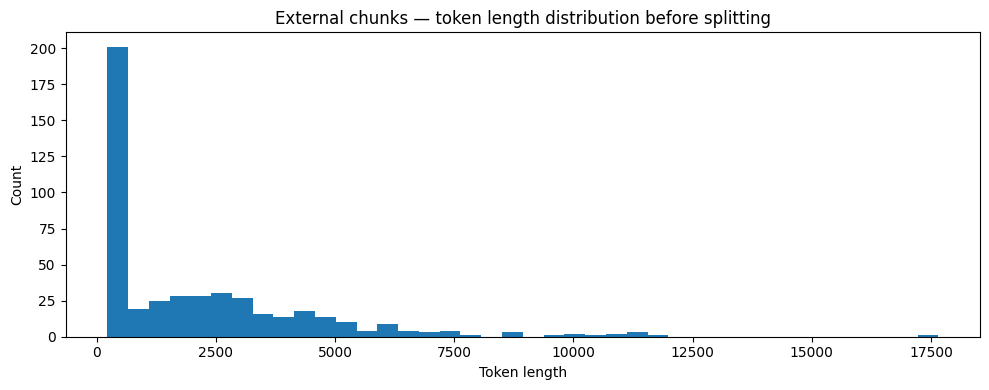

Mean:               2170.8
Median:             1329.0
95th percentile:    6627.4
Max:                17657
Chunks > 50 tokens: 469

SPLITTING LONG CHUNKS
Records before splitting: 469
Chunks after splitting:   40629
Max token length:         46
Chunks > 50:         0
All chunks respect MAX_TOKENS.



,chunk_id,text,source,label,url,symbol_name,slug,website,original_token_length,token_length
0,0,[hate] 1-11: ) ) ) email share all the symbols...,adl,hate,https://www.adl.org/resources/hate-symbol/1-11,1-11,1-11,https://www.adl.org/resources/hate-symbol,237,42
1,1,[hate] 1-11: few symbols represent just one id...,adl,hate,https://www.adl.org/resources/hate-symbol/1-11,1-11,1-11,https://www.adl.org/resources/hate-symbol,237,42
2,2,[hate] 1-11: or an expression and it is also u...,adl,hate,https://www.adl.org/resources/hate-symbol/1-11,1-11,1-11,https://www.adl.org/resources/hate-symbol,237,42
3,3,"[hate] 1-11: similarly, other symbols in this ...",adl,hate,https://www.adl.org/resources/hate-symbol/1-11,1-11,1-11,https://www.adl.org/resources/hate-symbol,237,42
4,4,[hate] 1-11: multiple meanings but may not be ...,adl,hate,https://www.adl.org/resources/hate-symbol/1-11,1-11,1-11,https://www.adl.org/resources/hate-symbol,237,42
5,5,"[hate] 1-11: brotherhood forever may 03, 2022 ...",adl,hate,https://www.adl.org/resources/hate-symbol/1-11,1-11,1-11,https://www.adl.org/resources/hate-symbol,237,42
6,6,"[hate] 1-11: 211 crew may 03, 2022 hate on dis...",adl,hate,https://www.adl.org/resources/hate-symbol/1-11,1-11,1-11,https://www.adl.org/resources/hate-symbol,237,42
7,7,[hate] 1-11: prison gang symbols xx min read 1...,adl,hate,https://www.adl.org/resources/hate-symbol/1-11,1-11,1-11,https://www.adl.org/resources/hate-symbol,237,42
8,8,"[hate] 1-11: gang, to identify themselves. sub...",adl,hate,https://www.adl.org/resources/hate-symbol/1-11,1-11,1-11,https://www.adl.org/resources/hate-symbol,237,37
9,9,[hate] 100%: ) ) ) email share all the symbols...,adl,hate,https://www.adl.org/resources/hate-symbol/100,100%,100,https://www.adl.org/resources/hate-symbol,386,42


TOKEN LENGTH CHECK AFTER SPLITTING


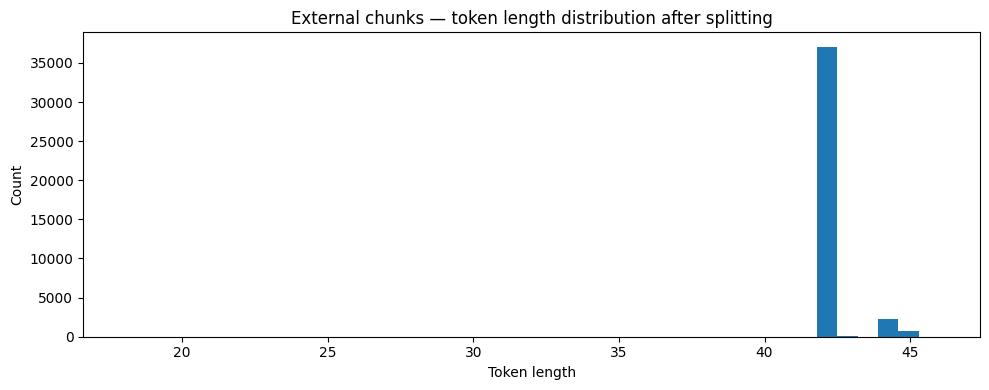

Mean:               42.0
Median:             42.0
95th percentile:    44.0
Max:                46
Chunks > 50 tokens: 0

SAVING ADL + SPLC PAGE CHUNKS
Saved ADL + SPLC backup files:
  documents/external_symbols_adl_splc.csv
  documents/external_symbols_adl_splc_with_urls.csv
Rows: 40629

Source counts:
source
splc    37429
adl      3200
Name: count, dtype: int64


In [ ]:
# -------------------------------
# Helper functions for page normalization and parsing
# -------------------------------

def normalize_firecrawl_page(page, requested_url=None):
    """
    Convert Firecrawl output into a stable dict:
      {
        "markdown": "...",
        "metadata": {
            "url": "...",
            "title": "...",
            "status_code": ...
        }
      }
    """
    markdown = get_field(page, "markdown", "") or ""

    metadata = get_field(page, "metadata", {}) or {}

    if isinstance(metadata, dict):
        url = (
            metadata.get("sourceURL")
            or metadata.get("source_url")
            or metadata.get("url")
            or requested_url
            or ""
        )
        title = metadata.get("title", "") or ""
        status_code = (
            metadata.get("statusCode")
            or metadata.get("status_code")
            or ""
        )
    else:
        url = (
            getattr(metadata, "sourceURL", None)
            or getattr(metadata, "source_url", None)
            or getattr(metadata, "url", None)
            or requested_url
            or ""
        )
        title = getattr(metadata, "title", "") or ""
        status_code = (
            getattr(metadata, "statusCode", None)
            or getattr(metadata, "status_code", None)
            or ""
        )

    return {
        "markdown": markdown,
        "metadata": {
            "url": url,
            "title": title,
            "status_code": status_code,
        },
    }


def get_metadata(page):
    """
    Get metadata from normalized page.
    """
    meta = page.get("metadata", {}) or {}

    return {
        "url": meta.get("url", "") or "",
        "title": meta.get("title", "") or "",
        "status_code": meta.get("status_code", "") or "",
    }


def clean_markdown_body(body):
    """
    Remove markdown formatting and website UI boilerplate.
    """
    body = str(body)

    # Remove images and markdown links
    body = re.sub(r"!\[.*?\]\(.*?\)", " ", body)
    body = re.sub(r"\[([^\]]+)\]\([^\)]+\)", r"\1", body)

    # Remove common sharing/printing UI junk
    ui_junk_patterns = [
        r"Open Sharing Options",
        r"Close Sharing Options",
        r"Print Content",
        r"Share on Facebook",
        r"Share on Twitter",
        r"Share on LinkedIn",
        r"Email this page",
        r"Copy Link",
        r"Copied to clipboard",
        r'["“”]*\(?opens in a new (?:window|tab)\)?["“”]*',
    ]

    for pat in ui_junk_patterns:
        body = re.sub(pat, " ", body, flags=re.IGNORECASE)

    # Remove markdown syntax
    body = re.sub(r"#{1,6}\s+", " ", body)
    body = re.sub(r"\*{1,2}([^*]+)\*{1,2}", r"\1", body)
    body = re.sub(r"`([^`]+)`", r"\1", body)

    # Clean leftover punctuation from removed UI snippets
    body = re.sub(r"\(\s*\)", " ", body)
    body = re.sub(r'"\s*"', " ", body)
    body = re.sub(r"\s+", " ", body).strip()

    return body

# ------------------------------------------------------------
# 4. Read website + slug sources from TXT file
# ------------------------------------------------------------

source_txt = "documents/symbol_sources.txt"

print("=" * 80)
print("READING SOURCE TXT FILE")
print("=" * 80)
print("Source file:", source_txt)
print()

if not os.path.exists(source_txt):
    raise FileNotFoundError(
        f"Could not find {source_txt}.\n\n"
        "Create this file with lines like:\n"
        "https://www.adl.org/resources/hate-symbol,88\n"
        "https://www.adl.org/resources/hate-symbol,sonnenrad"
    )

source_rows = []

with open(source_txt, "r", encoding="utf-8") as f:
    for line_num, line in enumerate(f, start=1):
        original_line = line
        line = line.strip()

        # Skip empty lines and comments
        if not line or line.startswith("#"):
            continue

        parts = [p.strip() for p in line.split(",", maxsplit=1)]

        if len(parts) != 2:
            print(f"Skipping line {line_num}: expected website,slug but got: {original_line!r}")
            continue

        website, slug = parts

        website = website.rstrip("/")
        slug = slug.strip("/")

        if not website or not slug:
            print(f"Skipping line {line_num}: empty website or slug: {original_line!r}")
            continue

        url = f"{website}/{slug}"

        # Infer source from domain/path : ADL & SPLC
        website_l = website.lower()
        if "adl.org" in website_l:
            source = "adl"
        elif "splcenter.org" in website_l:
            source = "splc"
        elif "hatebase.org" in website_l:
            source = "hatebase"
        else:
            source = "external"

        source_rows.append({
            "line_num": line_num,
            "website": website,
            "slug": slug,
            "url": url,
            "source": source,
            "label": "hate",
        })

df_sources = pd.DataFrame(source_rows)

if len(df_sources) == 0:
    raise ValueError(f"No valid source rows found in {source_txt}")

df_sources = df_sources.drop_duplicates(subset=["url"]).reset_index(drop=True)

print("Rows loaded:", len(source_rows))
print("Unique URLs:", len(df_sources))
print("Unique websites:", df_sources["website"].nunique())
print()

display(df_sources.head(20))


# ------------------------------------------------------------
# 5. Scrape individual source pages
# ------------------------------------------------------------

print("=" * 80)
print("SCRAPING INDIVIDUAL SOURCE PAGES")
print("=" * 80)

raw_pages = []
failed_urls = []

print("URLs to scrape:", len(df_sources))
print()

for i, row in df_sources.iterrows():
    url = row["url"]
    source = row.get("source", "external")
    label = row.get("label", "hate")
    slug = row.get("slug", "")
    website = row.get("website", "")

    print(f"[{i + 1}/{len(df_sources)}] Scraping: {url}")

    try:
        page_raw = firecrawl.scrape(
            url,
            formats=["markdown"],
            only_main_content=True,
        )

        page = normalize_firecrawl_page(page_raw, requested_url=url)

        # Attach TXT metadata to the page
        page["txt_source"] = source
        page["txt_label"] = label
        page["txt_slug"] = slug
        page["txt_website"] = website
        page["txt_line_num"] = row.get("line_num", "")

        md = page["markdown"]
        meta = get_metadata(page)

        print("  Markdown length:", len(md))
        print("  Title:          ", meta["title"])
        print("  Source:         ", source)
        print("  Label:          ", label)
        print("  Preview:        ", preview_text(md, 220))

        is_404_like = (
            "Page Not Found" in md[:500]
            or "couldn't find the page" in md[:1000].lower()
            or "404" in meta["title"].lower()
            or "page not found" in meta["title"].lower()
        )

        if is_404_like:
            failed_urls.append((url, "page not found / invalid slug"))
            print("  Result:          FAILED — page not found")
        elif len(md.strip()) >= 50:
            raw_pages.append(page)
            print("  Result:          OK")
        else:
            failed_urls.append((url, "markdown too short"))
            print("  Result:          FAILED — markdown too short")

    except Exception as e:
        failed_urls.append((url, f"{type(e).__name__}: {e}"))
        print("  Result:          FAILED")
        print("  Error type:      ", type(e).__name__)
        print("  Error message:   ", str(e))

    print("-" * 80)

print()
print("=" * 80)
print("SCRAPE SUMMARY")
print("=" * 80)
print("Attempted:", len(df_sources))
print("Succeeded:", len(raw_pages))
print("Failed:   ", len(failed_urls))

if failed_urls:
    print()
    print("First failed URLs:")
    for url, reason in failed_urls[:20]:
        print("-", url, "|", reason)
    print()

if len(raw_pages) == 0:
    raise ValueError("No pages were scraped successfully.")


# ------------------------------------------------------------
# 6. Inspect scraped pages
# ------------------------------------------------------------

print("=" * 80)
print("SCRAPED PAGE OVERVIEW")
print("=" * 80)

url_counter = Counter()

for i, page in enumerate(raw_pages[:20]):
    md = page["markdown"]
    meta = get_metadata(page)

    url = meta["url"]
    title = meta["title"]

    if url:
        url_counter[url] += 1

    print(f"[PAGE {i}]")
    print("URL:             ", url)
    print("Title:           ", title)
    print("Status code:     ", meta["status_code"])
    print("Markdown length: ", len(md))
    print("Markdown preview:", preview_text(md, 280))
    print("-" * 80)

if len(raw_pages) > 20:
    print(f"...showing first 20 of {len(raw_pages)} pages.")
    print()

print("Unique URLs scraped:", len(url_counter))
print()


# ------------------------------------------------------------
# 7. Parse markdown into records
# ------------------------------------------------------------

print("=" * 80)
print("PARSING PAGES")
print("=" * 80)

skip_reasons = Counter()

def clean_splc_name(name, slug=""):
    """
    Clean SPLC entity names.
    Falls back to slug if name is generic.
    """
    name = str(name).strip()

    name = re.sub(r"\s*\|.*$", "", name).strip()
    name = re.sub(r"\s*- Southern Poverty Law Center.*$", "", name).strip()
    name = re.sub(r"\s*Southern Poverty Law Center\s*", "", name).strip()
    name = re.sub(r"\s+", " ", name).strip()

    bad_names = {
        "",
        "in this article",
        "notifications",
        "extremist files",
        "share",
        "related",
        "resources",
    }

    if name.lower() in bad_names:
        name = slug.replace("-", " ").title()

    return name


def extract_splc_record(md, meta_title, url, slug, website, label="hate", debug=False, prefix=""):
    """
    SPLC pages often look like:

      Cliff Kincaid
      Related: ...
      Born: ...
      Location: ...
      Share
      In this article
      In his own words
      Background
      Main body...

    This parser:
      - gets entity name from first meaningful line / metadata / slug
      - removes SPLC navigation/sidebar/footer boilerplate
      - keeps the article body
    """

    original_md = md

    # Step 1- Remove top site navigation boilerplate
    md = re.sub(r"(?is)^.*?Toggle Search\s*", " ", md)
    md = re.sub(r"(?is)^.*?Open Menu\s*", " ", md)

    # Step 2- Split into non-empty lines
    lines = [line.strip() for line in md.splitlines() if line.strip()]

    if len(lines) == 0:
        skip_reasons["splc_no_lines"] += 1
        if debug:
            print(prefix + "SKIP SPLC: no usable lines")
        return None

    # Step 3- Find name
    bad_line_starts = (
        "related:",
        "born:",
        "location:",
        "share",
        "open dialog",
        "in this article",
        "notifications",
        "citations",
        "get the latest",
        "email",
        "subscribe",
    )

    name = ""

    # Prefer metadata title if it is useful
    if meta_title:
        candidate = clean_splc_name(meta_title, slug)
        if candidate and candidate.lower() not in {"extremist files", "in this article"}:
            name = candidate

    # Otherwise first meaningful line
    if not name:
        for line in lines[:30]:
            line_clean = re.sub(r"^#{1,6}\s*", "", line).strip()
            line_l = line_clean.lower()

            if any(line_l.startswith(x) for x in bad_line_starts):
                continue

            # Skip image alt-ish lines
            if "splc-extremist-files" in line_l:
                continue

            if len(line_clean) < 2:
                continue

            name = clean_splc_name(line_clean, slug)
            break

    # Final fallback
    if not name:
        name = slug.replace("-", " ").title()

    name = clean_splc_name(name, slug)

    # Step 4- Extract useful body
    body = md

    # Remove everything before the entity name if possible
    name_pattern = re.escape(name)
    body = re.sub(rf"(?is)^.*?{name_pattern}\s*", " ", body, count=1)

    # Remove SPLC metadata/sidebar lines
    body = re.sub(r"(?im)^Related:\s*.*$", " ", body)
    body = re.sub(r"(?im)^Born:\s*.*$", " ", body)
    body = re.sub(r"(?im)^Location:\s*.*$", " ", body)
    body = re.sub(r"(?im)^Share\s*$", " ", body)
    body = re.sub(r"(?im)^\(Open dialog with sharing options\)\s*$", " ", body)
    body = re.sub(r"(?im)^SPLC-Extremist-Files-[^\n]+$", " ", body)

    # Remove "In this article" table-of-contents block.
    # Usually followed by section labels and then the real article begins.
    body = re.sub(r"(?im)^In this article\s*$", " ", body)

    # Remove standalone section TOC labels only near top-ish text.
    # The real headings can remain later in body after cleaning.
    body = re.sub(r"(?im)^\s*In his own words\s*$", " In his own words ", body)
    body = re.sub(r"(?im)^\s*Background\s*$", " Background ", body)

    # Remove footer from Citations onward
    body = re.sub(r"(?is)\bCitations\s+Get the latest updates from.*$", " ", body)
    body = re.sub(r"(?is)\bGet the latest updates from\s+Southern Poverty Law Center.*$", " ", body)
    body = re.sub(r"(?is)\bRacial Justice Issues\s+Find Resources.*$", " ", body)
    body = re.sub(r"(?is)\bPrivacy & Terms\s+Accessibility Statement.*$", " ", body)

    # Remove SPLC responsive-page notification
    body = re.sub(
        r"(?is)Some areas of this page may shift around if you resize the browser window\.?\s*Be sure to check heading and document order\.?",
        " ",
        body,
    )

    # Use your existing markdown cleaner
    body = clean_markdown_body(body)

    # Extra cleanup
    body = re.sub(r"\bSkip to content\b", " ", body, flags=re.IGNORECASE)
    body = re.sub(r"\bClose Alert\b", " ", body, flags=re.IGNORECASE)
    body = re.sub(r"\bSPLC Home\b", " ", body, flags=re.IGNORECASE)
    body = re.sub(r"\bToggle Search\b", " ", body, flags=re.IGNORECASE)
    body = re.sub(r"\bOpen Menu\b", " ", body, flags=re.IGNORECASE)
    body = re.sub(r"\bIn this article\b", " ", body, flags=re.IGNORECASE)
    body = re.sub(r"\s+", " ", body).strip()

    # Step 5- Validate
    if len(body) < 50:
        skip_reasons["splc_body_too_short"] += 1
        if debug:
            print(prefix + "SKIP SPLC: body too short")
            print(prefix + f"Name: {name!r}")
            print(prefix + f"Body preview: {preview_text(body, 300)}")
        return None

    if debug:
        print(prefix + "PARSED SPLC OK")
        print(prefix + f"Name: {name}")
        print(prefix + f"Slug: {slug}")
        print(prefix + f"Body length: {len(body)}")
        print(prefix + f"Body preview: {preview_text(body, 400)}")

    return {
        "name": name,
        "body": body,
        "url": url,
        "source": "splc",
        "label": label,
        "slug": slug,
        "website": website,
    }


def extract_record(page, debug=False, page_idx=None):
    """
    Parse one normalized Firecrawl page into:
      - name
      - body
      - url
      - source
      - label
      - slug
      - website

    Uses special parsing for SPLC pages because their first heading/sidebar
    often contains "In this article" rather than the actual entity name.
    """
    md = page["markdown"] or ""
    meta = get_metadata(page)

    url = meta["url"]
    meta_title = meta["title"]

    source = page.get("txt_source", "external")
    label = page.get("txt_label", "hate")
    slug = page.get("txt_slug", "")
    website = page.get("txt_website", "")

    prefix = f"[PARSE PAGE {page_idx}] " if page_idx is not None else ""

    if len(md.strip()) < 50:
        skip_reasons["markdown_too_short"] += 1
        if debug:
            print(prefix + "SKIP: markdown too short")
        return None

    if "Page Not Found" in md[:500] or "couldn't find the page" in md[:1000].lower():
        skip_reasons["page_not_found"] += 1
        if debug:
            print(prefix + "SKIP: page not found")
        return None

    # ------------------------------------------------------------
    # SPLC-specific parser
    # ------------------------------------------------------------
    if source == "splc":
        rec = extract_splc_record(
            md=md,
            meta_title=meta_title,
            url=url,
            slug=slug,
            website=website,
            label=label,
            debug=debug,
            prefix=prefix,
        )

        if rec is None:
            return None

        skip_reasons["parsed_successfully"] += 1
        return rec

    # ------------------------------------------------------------
    # Generic / ADL parser
    # ------------------------------------------------------------

    heading_match = re.search(r"^#{1,3}\s+(.+)", md, re.MULTILINE)

    if heading_match:
        name = heading_match.group(1).strip()
        body = md[heading_match.end():].strip()
        name_source = "markdown heading"
    elif meta_title:
        name = str(meta_title).strip()
        body = md.strip()
        name_source = "metadata title"
    else:
        name = slug.replace("-", " ").strip()
        body = md.strip()
        name_source = "slug fallback"

    # Clean name
    name = re.sub(r"\s*\|.*$", "", name).strip()
    name = re.sub(r"\s*- Anti-Defamation League.*$", "", name).strip()
    name = re.sub(r"\s*Hate Symbols Database\s*", "", name).strip()
    name = re.sub(r"\s+", " ", name).strip()

    if not name:
        skip_reasons["missing_name"] += 1
        if debug:
            print(prefix + "SKIP: missing name")
        return None

    bad_titles = [
        "search",
        "browse",
        "all symbols",
        "hate symbols database",
        "hate symbols",
        "page not found",
        "in this article",
        "notifications",
    ]

    if name.lower().strip() in bad_titles:
        skip_reasons["index_or_listing_page"] += 1
        if debug:
            print(prefix + f"SKIP: index/listing title: {name!r}")
        return None

    body_before_cleaning_len = len(body)
    body = clean_markdown_body(body)

    if len(body) < 50:
        skip_reasons["body_too_short_after_cleaning"] += 1
        if debug:
            print(prefix + "SKIP: body too short after cleaning")
            print(prefix + f"Name: {name!r}")
            print(prefix + f"Body length before cleaning: {body_before_cleaning_len}")
            print(prefix + f"Body length after cleaning: {len(body)}")
        return None

    skip_reasons["parsed_successfully"] += 1

    if debug:
        print(prefix + "PARSED OK")
        print(prefix + f"Name source: {name_source}")
        print(prefix + f"Name: {name}")
        print(prefix + f"Source: {source}")
        print(prefix + f"Label: {label}")
        print(prefix + f"Body length: {len(body)}")
        print(prefix + f"Body preview: {preview_text(body, 300)}")

    return {
        "name": name,
        "body": body,
        "url": url,
        "source": source,
        "label": label,
        "slug": slug,
        "website": website,
    }

parsed = []

for i, page in enumerate(raw_pages):
    debug_this_page = i < 15

    rec = extract_record(
        page,
        debug=debug_this_page,
        page_idx=i,
    )

    if rec:
        parsed.append(rec)

    if i < 15:
        print("-" * 80)

    if (i + 1) % 50 == 0:
        print(f"Progress: checked {i + 1}/{len(raw_pages)} pages; parsed {len(parsed)} so far.")

print()
print("=" * 80)
print("PARSE SUMMARY")
print("=" * 80)
print("Pages scraped:", len(raw_pages))
print("Pages parsed: ", len(parsed))
print()

print("Skip / parse reasons:")
for reason, count in skip_reasons.most_common():
    print(f"  {reason:35s} {count}")

print()

if len(parsed) == 0:
    raise ValueError("Parsed zero pages. See debug output above.")

print("Sample parsed entries:")
for i, rec in enumerate(parsed[:5]):
    print("=" * 80)
    print(f"SAMPLE {i}")
    print("Name:", rec["name"])
    print("Source:", rec["source"])
    print("Label:", rec["label"])
    print("URL: ", rec["url"])
    print("Body:", preview_text(rec["body"], 600))

print("=" * 80)
print("PARSING COMPLETE")
print("=" * 80)
print()


# ------------------------------------------------------------
# 8. Build initial chunks
# ------------------------------------------------------------

print("=" * 80)
print("BUILDING INITIAL CHUNKS")
print("=" * 80)

records = []

for rec in parsed:
    label = rec.get("label", "hate")
    source = rec.get("source", "external")

    text = f"[{label}] {rec['name']}: {rec['body']}"
    text = re.sub(r"\s+", " ", text).strip()

    records.append({
        "text": text,
        "source": source,
        "label": label,
        "url": rec["url"],
        "symbol_name": rec["name"],
        "slug": rec.get("slug", ""),
        "website": rec.get("website", ""),
    })

df_initial = pd.DataFrame(records)
df_initial.insert(0, "chunk_id", range(len(df_initial)))

print("Parsed records:", len(parsed))
print("Initial chunks:", len(df_initial))
print()

display(df_initial.head(5))


# ------------------------------------------------------------
# 9. !! Check token length before splitting
# ------------------------------------------------------------

print("=" * 80)
print("TOKEN LENGTH CHECK BEFORE SPLITTING")
print("=" * 80)

tokenizer = AutoTokenizer.from_pretrained("GroNLP/hateBERT")

token_lengths = [
    len(tokenizer.encode(t, add_special_tokens=False))
    for t in df_initial["text"]
]

df_initial["token_length"] = token_lengths

plt.figure(figsize=(10, 4))
plt.hist(token_lengths, bins=40)
plt.xlabel("Token length")
plt.ylabel("Count")
plt.title("External chunks — token length distribution before splitting")
plt.tight_layout()
plt.show()

print(f"Mean:               {np.mean(token_lengths):.1f}")
print(f"Median:             {np.median(token_lengths):.1f}")
print(f"95th percentile:    {np.percentile(token_lengths, 95):.1f}")
print(f"Max:                {max(token_lengths)}")
print(f"Chunks > 50 tokens: {sum(l > 50 for l in token_lengths)}")
print()


# ------------------------------------------------------------
# 10. Split chunks that are too long into smaller windows with overlap
# ------------------------------------------------------------

print("=" * 80)
print("SPLITTING LONG CHUNKS")
print("=" * 80)

MAX_TOKENS = 50
STRIDE_TOKENS = 25
SAFETY_MARGIN = 8


def token_len(text):
    return len(tokenizer.encode(text, add_special_tokens=False))


def force_token_limit(text, max_tok=50):
    """
    Final safety check after decode/re-encode.
    Keeps truncating until encoded text is <= max_tok.
    """
    text = re.sub(r"\s+", " ", str(text)).strip()

    while token_len(text) > max_tok:
        toks = tokenizer.encode(text, add_special_tokens=False)
        toks = toks[:max_tok]
        text = tokenizer.decode(toks, skip_special_tokens=True)
        text = re.sub(r"\s+", " ", text).strip()

        if token_len(text) <= max_tok:
            break

        max_tok -= 1

    return text


def split_into_windows(name, body, label="hate", max_tok=50, stride=25):
    """
    Split body into overlapping token windows.
    Every final output is guaranteed to retokenize to <= max_tok.
    """
    prefix = f"[{label}] {name}: "

    prefix_toks = tokenizer.encode(prefix, add_special_tokens=False)
    body_toks = tokenizer.encode(body, add_special_tokens=False)

    budget = max_tok - len(prefix_toks) - SAFETY_MARGIN

    if budget <= 0:
        combined_toks = prefix_toks + body_toks
        text = tokenizer.decode(combined_toks[:max_tok], skip_special_tokens=True)
        return [force_token_limit(text, max_tok)]

    windows = []
    start = 0

    while start < len(body_toks):
        window_toks = body_toks[start:start + budget]

        if not window_toks:
            break

        window_text = tokenizer.decode(
            window_toks,
            skip_special_tokens=True,
        )

        text = prefix + window_text
        text = re.sub(r"\s+", " ", text).strip()
        text = force_token_limit(text, max_tok)

        windows.append(text)

        if start + budget >= len(body_toks):
            break

        start += stride

    return windows


final_records = []

for rec in parsed:
    label = rec.get("label", "hate")
    source = rec.get("source", "external")

    full_text = f"[{label}] {rec['name']}: {rec['body']}"
    full_text = re.sub(r"\s+", " ", full_text).strip()

    n_tok = token_len(full_text)

    if n_tok <= MAX_TOKENS:
        final_records.append({
            "text": force_token_limit(full_text, MAX_TOKENS),
            "source": source,
            "label": label,
            "url": rec["url"],
            "symbol_name": rec["name"],
            "slug": rec.get("slug", ""),
            "website": rec.get("website", ""),
            "original_token_length": n_tok,
        })
    else:
        windows = split_into_windows(
            name=rec["name"],
            body=rec["body"],
            label=label,
            max_tok=MAX_TOKENS,
            stride=STRIDE_TOKENS,
        )

        for window in windows:
            final_records.append({
                "text": force_token_limit(window, MAX_TOKENS),
                "source": source,
                "label": label,
                "url": rec["url"],
                "symbol_name": rec["name"],
                "slug": rec.get("slug", ""),
                "website": rec.get("website", ""),
                "original_token_length": n_tok,
            })

df_final = pd.DataFrame(final_records)
df_final.insert(0, "chunk_id", range(len(df_final)))

lengths_after = [
    token_len(t)
    for t in df_final["text"]
]

df_final["token_length"] = lengths_after

print("Records before splitting:", len(parsed))
print("Chunks after splitting:  ", len(df_final))
print("Max token length:        ", max(lengths_after))
print(f"Chunks > {MAX_TOKENS}:        ", sum(l > MAX_TOKENS for l in lengths_after))

offenders = df_final[df_final["token_length"] > MAX_TOKENS]

if len(offenders) > 0:
    print("\nOffending chunks:")
    display(offenders[["chunk_id", "symbol_name", "token_length", "text"]].head(20))

assert max(lengths_after) <= MAX_TOKENS, "Some chunks still exceed MAX_TOKENS!"

print("All chunks respect MAX_TOKENS.")
print()

display(df_final.head(10))


# ------------------------------------------------------------
# 11. Sanity check : Token length after splitting
# ------------------------------------------------------------

print("=" * 80)
print("TOKEN LENGTH CHECK AFTER SPLITTING")
print("=" * 80)

plt.figure(figsize=(10, 4))
plt.hist(lengths_after, bins=40)
plt.xlabel("Token length")
plt.ylabel("Count")
plt.title("External chunks — token length distribution after splitting")
plt.tight_layout()
plt.show()

print(f"Mean:               {np.mean(lengths_after):.1f}")
print(f"Median:             {np.median(lengths_after):.1f}")
print(f"95th percentile:    {np.percentile(lengths_after, 95):.1f}")
print(f"Max:                {max(lengths_after)}")
print(f"Chunks > 50 tokens: {sum(l > 50 for l in lengths_after)}")
print()


# ------------------------------------------------------------
# 12. Save outputs
# ------------------------------------------------------------

print("=" * 80)
print("SAVING ADL + SPLC PAGE CHUNKS")
print("=" * 80)

os.makedirs("documents", exist_ok=True)

df_page_chunks = df_final.copy()

df_page_chunks[["chunk_id", "text"]].to_csv(
    "documents/external_symbols_adl_splc.csv",
    index=False,
)

df_page_chunks.to_csv(
    "documents/external_symbols_adl_splc_with_urls.csv",
    index=False,
)

print("Saved ADL + SPLC backup files:")
print("  documents/external_symbols_adl_splc.csv")
print("  documents/external_symbols_adl_splc_with_urls.csv")
print("Rows:", len(df_page_chunks))
print()

print("Source counts:")
print(df_page_chunks["source"].value_counts())

In [ ]:
# ------------------------------------------------------------
# 13. Hatebase filtered terms extraction
# ------------------------------------------------------------
"""
 It scrapes selected English-filtered categories that were chosen 
 as most relevant to our use case, based on the Hatebase taxonomy:

   - English overall
   - Ethnicities: African, African American, Arabs
   - Sexual orientation: homosexuals
   - Gender: female, transgender
   - Religions: Islam, Judaism

 Output:
   documents/sources/hatebase_terms.csv
   documents/sources/hatebase_filter_logs.csv
"""

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def clean_hatebase_cell(text):
    """
    Clean one markdown table cell.
    Handles markdown links and HTML line breaks.
    """
    text = str(text).strip()

    # HTML breaks -> space
    text = re.sub(r"<br\s*/?>", " ", text, flags=re.IGNORECASE)

    # Markdown link -> visible text
    text = re.sub(r"\[([^\]]+)\]\([^\)]+\)", r"\1", text)

    # Remove bold/italic markdown
    text = re.sub(r"\*+", "", text)

    # Remove remaining simple HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Collapse whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


def parse_hatebase_rows(markdown):
    """
    Parse Hatebase Firecrawl markdown table rows.

    Expected markdown looks like:
      | [6 gorillion](...) | English | 1 sighting | Highly offensive |
    """
    rows = []

    for raw_line in markdown.splitlines():
        line = raw_line.strip()

        if not line:
            continue

        # Keep only markdown table rows
        if not line.startswith("|"):
            continue

        # Skip separator rows like:
        # | --- | --- | --- | --- |
        if re.match(r"^\|\s*:?-+:?\s*(\|\s*:?-+:?\s*)+\|?$", line):
            continue

        # Split markdown table row
        parts = [p.strip() for p in line.strip("|").split("|")]

        if len(parts) < 4:
            continue

        term = clean_hatebase_cell(parts[0])
        language = clean_hatebase_cell(parts[1])
        sightings = clean_hatebase_cell(parts[2])
        offensiveness = clean_hatebase_cell(parts[3])

        # Skip empty/header/UI rows
        if not term:
            continue

        if term.lower() in {"term", "vocabulary", "read faqs"}:
            continue

        if language.lower() in {"language", "select"}:
            continue

        if not language and not sightings and not offensiveness:
            continue

        rows.append({
            "term": term,
            "language": language,
            "sightings": sightings,
            "offensiveness": offensiveness,
        })

    return rows


def extract_showing_range(markdown):
    """
    Extract text like:
      Showing 1 - 50 of 3,893 results
    """
    match = re.search(
        r"Showing\s+([\d,]+)\s*-\s*([\d,]+)\s+of\s+([\d,]+)\s+results",
        markdown,
        flags=re.IGNORECASE,
    )

    if not match:
        return None

    return {
        "start": match.group(1),
        "end": match.group(2),
        "total": match.group(3),
        "raw": match.group(0),
    }


# ------------------------------------------------------------
# Config : Hatebase filtered URLs
# ------------------------------------------------------------

hatebase_filters = [
    {
        "filter_group": "language",
        "filter_name": "english_all",
        "target_category": "english",
        "url": "https://hatebase.org/search_results/language_id%3Deng",
    },

    # Ethnicities
    {
        "filter_group": "ethnicity",
        "filter_name": "african",
        "target_category": "African",
        "url": "https://hatebase.org/search_results/ethnicity_id%3D300%7Clanguage_id%3Deng",
    },
    {
        "filter_group": "ethnicity",
        "filter_name": "african_american",
        "target_category": "African American",
        "url": "https://hatebase.org/search_results/ethnicity_id%3D5%7Clanguage_id%3Deng",
    },
    {
        "filter_group": "ethnicity",
        "filter_name": "arabs",
        "target_category": "Arabs",
        "url": "https://hatebase.org/search_results/ethnicity_id%3D14%7Clanguage_id%3Deng",
    },

    # Sexual orientation
    {
        "filter_group": "sexual_orientation",
        "filter_name": "homosexuals",
        "target_category": "Homosexuals",
        "url": "https://hatebase.org/search_results/orientation_id%3D3%7Clanguage_id%3Deng",
    },

    # Gender
    {
        "filter_group": "gender",
        "filter_name": "female",
        "target_category": "Female",
        "url": "https://hatebase.org/search_results/gender_id%3D6%7Clanguage_id%3Deng",
    },
    {
        "filter_group": "gender",
        "filter_name": "transgender",
        "target_category": "Transgender",
        "url": "https://hatebase.org/search_results/gender_id%3D14%7Clanguage_id%3Deng",
    },

    # Religions
    {
        "filter_group": "religion",
        "filter_name": "islam",
        "target_category": "Islam",
        "url": "https://hatebase.org/search_results/religion_id%3D11%7Clanguage_id%3Deng",
    },
    {
        "filter_group": "religion",
        "filter_name": "judaism",
        "target_category": "Judaism",
        "url": "https://hatebase.org/search_results/religion_id%3D14%7Clanguage_id%3Deng",
    },
]


# Scraping filtered Hatebase URLs
print("=" * 80)
print("SCRAPING FILTERED HATEBASE SEARCH RESULTS")
print("=" * 80)

all_rows = []
page_logs = []

for i, spec in enumerate(hatebase_filters, start=1):
    url = spec["url"]
    filter_group = spec["filter_group"]
    filter_name = spec["filter_name"]
    target_category = spec["target_category"]

    print(f"[{i}/{len(hatebase_filters)}] Scraping Hatebase filter:")
    print("  Group:   ", filter_group)
    print("  Name:    ", filter_name)
    print("  Category:", target_category)
    print("  URL:     ", url)

    try:
        page = firecrawl.scrape(
            url,
            formats=["markdown"],
            only_main_content=True,
        )

        markdown = get_field(page, "markdown", "") or ""
        rows = parse_hatebase_rows(markdown)
        showing_range = extract_showing_range(markdown)
        showing_raw = showing_range["raw"] if showing_range else ""

        first_terms = tuple(r["term"] for r in rows[:5])

        print("  Markdown length:", len(markdown))
        print("  Showing range:  ", showing_raw if showing_raw else "not found")
        print("  Rows parsed:    ", len(rows))
        print("  First terms:    ", first_terms)
        print("  Preview:        ", preview_text(markdown, 220))

        for row in rows:
            row["source"] = "hatebase"
            row["label"] = "hate"
            row["source_url"] = url
            row["filter_group"] = filter_group
            row["filter_name"] = filter_name
            row["target_category"] = target_category
            row["showing_range"] = showing_raw
            row["coverage_note"] = "selected_english_filters"

        all_rows.extend(rows)

        page_logs.append({
            "filter_group": filter_group,
            "filter_name": filter_name,
            "target_category": target_category,
            "url": url,
            "markdown_length": len(markdown),
            "rows_found": len(rows),
            "showing_range": showing_raw,
            "first_terms": first_terms,
            "status": "ok",
        })

    except Exception as e:
        print("  FAILED:", type(e).__name__, str(e))

        page_logs.append({
            "filter_group": filter_group,
            "filter_name": filter_name,
            "target_category": target_category,
            "url": url,
            "markdown_length": 0,
            "rows_found": 0,
            "showing_range": "",
            "first_terms": (),
            "status": f"failed: {type(e).__name__}: {e}",
        })

    print("-" * 80)


# Build Hatebase dataframe & Save outputs
df_hatebase = pd.DataFrame(all_rows)

print()
print("=" * 80)
print("HATEBASE RAW EXTRACTION SUMMARY")
print("=" * 80)
print("Raw rows parsed:", len(df_hatebase))
print("Filters attempted:", len(page_logs))

if len(df_hatebase) == 0:
    print("No Hatebase rows parsed.")
    print("Check filter URLs and printed previews above.")
else:
    # Deduplicate by term/language, but preserve category info.
    # If the same term appears in multiple categories, this keeps the first occurrence.
    df_hatebase = df_hatebase.drop_duplicates(
        subset=["term", "language"]
    ).reset_index(drop=True)

    df_hatebase["text"] = df_hatebase.apply(
        lambda r: (
            f"[{r['label']}] {r['term']}: "
            f"Hatebase entry. Target category: {r['target_category']}. "
            f"Filter group: {r['filter_group']}. "
            f"Language: {r['language']}. "
            f"Offensiveness: {r['offensiveness']}. "
            f"Sightings: {r['sightings']}."
        ),
        axis=1,
    )

    os.makedirs("documents/sources", exist_ok=True)

    csv_path = "documents/sources/hatebase_terms.csv"
    log_path = "documents/sources/hatebase_filter_logs.csv"

    df_hatebase.to_csv(csv_path, index=False)
    pd.DataFrame(page_logs).to_csv(log_path, index=False)

    print()
    print("=" * 80)
    print("HATEBASE EXTRACTION SUMMARY")
    print("=" * 80)
    print("Unique rows parsed:", len(df_hatebase))
    print("Saved Hatebase terms CSV:", csv_path)
    print("Saved Hatebase logs CSV: ", log_path)
    print()

    print("Rows by filter group:")
    print(df_hatebase["filter_group"].value_counts())
    print()

    print("Rows by target category:")
    print(df_hatebase["target_category"].value_counts())
    print()

    print("Preview:")
    display(df_hatebase.head(20))

SCRAPING FILTERED HATEBASE SEARCH RESULTS
[1/9] Scraping Hatebase filter:
  Group:    language
  Name:     english_all
  Category: english
  URL:      https://hatebase.org/search_results/language_id%3Deng
  Markdown length: 11309
  Showing range:   Showing 1 - 50 of 1,565 results
  Rows parsed:     50
  First terms:     ('6 gorillion', 'abbo (variant of abo)', 'abbos (plural of abbo)', 'ABC', 'ABCD')
  Preview:         # Hatebase [![Hatebase](https://hatebase.org/resources/img/logo.png)](https://hatebase.org/) **Showing 1 - 50 of 1,565 results** [Read FAQs](https://hatebase.org/faqs) | | | | | | --- | --- | --- | --- | | [6 gorillion](...
--------------------------------------------------------------------------------
[2/9] Scraping Hatebase filter:
  Group:    ethnicity
  Name:     african
  Category: African
  URL:      https://hatebase.org/search_results/ethnicity_id%3D300%7Clanguage_id%3Deng
  Markdown length: 8187
  Showing range:   Showing 1 - 33 of 33 results
  Rows parsed:     

,term,language,sightings,offensiveness,source,label,source_url,filter_group,filter_name,target_category,showing_range,coverage_note,text
0,6 gorillion,English,1 sighting,Highly offensive,hatebase,hate,https://hatebase.org/search_results/language_i...,language,english_all,english,"Showing 1 - 50 of 1,565 results",selected_english_filters,[hate] 6 gorillion: Hatebase entry. Target cat...
1,abbo (variant of abo),English,-,Extremely offensive,hatebase,hate,https://hatebase.org/search_results/language_i...,language,english_all,english,"Showing 1 - 50 of 1,565 results",selected_english_filters,[hate] abbo (variant of abo): Hatebase entry. ...
2,abbos (plural of abbo),English,109 sightings,Extremely offensive,hatebase,hate,https://hatebase.org/search_results/language_i...,language,english_all,english,"Showing 1 - 50 of 1,565 results",selected_english_filters,[hate] abbos (plural of abbo): Hatebase entry....
3,ABC,English,1 sighting,Mildly offensive,hatebase,hate,https://hatebase.org/search_results/language_i...,language,english_all,english,"Showing 1 - 50 of 1,565 results",selected_english_filters,[hate] ABC: Hatebase entry. Target category: e...
4,ABCD,English,-,Mildly offensive,hatebase,hate,https://hatebase.org/search_results/language_i...,language,english_all,english,"Showing 1 - 50 of 1,565 results",selected_english_filters,[hate] ABCD: Hatebase entry. Target category: ...
5,ABCDs (plural of ABCD),English,-,Mildly offensive,hatebase,hate,https://hatebase.org/search_results/language_i...,language,english_all,english,"Showing 1 - 50 of 1,565 results",selected_english_filters,[hate] ABCDs (plural of ABCD): Hatebase entry....
6,ABCs (plural of ABC),English,2 sightings,Mildly offensive,hatebase,hate,https://hatebase.org/search_results/language_i...,language,english_all,english,"Showing 1 - 50 of 1,565 results",selected_english_filters,[hate] ABCs (plural of ABC): Hatebase entry. T...
7,abo,English,-,Highly offensive,hatebase,hate,https://hatebase.org/search_results/language_i...,language,english_all,english,"Showing 1 - 50 of 1,565 results",selected_english_filters,[hate] abo: Hatebase entry. Target category: e...
8,abos (plural of abo),English,82 sightings,Highly offensive,hatebase,hate,https://hatebase.org/search_results/language_i...,language,english_all,english,"Showing 1 - 50 of 1,565 results",selected_english_filters,[hate] abos (plural of abo): Hatebase entry. T...
9,af,English,-,Extremely offensive,hatebase,hate,https://hatebase.org/search_results/language_i...,language,english_all,english,"Showing 1 - 50 of 1,565 results",selected_english_filters,[hate] af: Hatebase entry. Target category: en...


In [ ]:
# ------------------------------------------------------------
# 13.2 Sanity Check: Hatebase Extraction Diagnostics
# ------------------------------------------------------------

print("=" * 80)
print("HATEBASE DIAGNOSTICS")
print("=" * 80)

if "df_hatebase" in globals() and isinstance(df_hatebase, pd.DataFrame):
    hb = df_hatebase.copy()
    print("Using dataframe: df_hatebase")
elif os.path.exists("documents/sources/hatebase_terms.csv"):
    hb = pd.read_csv("documents/sources/hatebase_terms.csv")
    print("Using file: documents/sources/hatebase_terms.csv")
else:
    raise FileNotFoundError("No df_hatebase found and no hatebase_terms.csv file exists.")

print()
print("Total rows:", len(hb))
print("Columns:", list(hb.columns))
print()


# Basic deduplication stats :
if {"term", "language"}.issubset(hb.columns):
    unique_term_lang = hb.drop_duplicates(subset=["term", "language"])
    print("Unique term-language pairs:", len(unique_term_lang))
    print("Duplicate term-language rows:", len(hb) - len(unique_term_lang))
    print()

if "term" in hb.columns:
    print("Unique terms:", hb["term"].nunique())
    print()


# Counts by filter/category :
for col in ["filter_group", "filter_name", "target_category", "language", "offensiveness"]:
    if col in hb.columns:
        print("=" * 80)
        print(f"COUNTS BY {col.upper()}")
        print("=" * 80)
        print(hb[col].fillna("").value_counts().head(30))
        print()


# Showing ranges :
if "showing_range" in hb.columns:
    print("=" * 80)
    print("SHOWING RANGES")
    print("=" * 80)
    print(hb["showing_range"].fillna("").value_counts())
    print()


# Source URLs / filters that contributed rows :
if "source_url" in hb.columns:
    print("=" * 80)
    print("ROWS BY SOURCE URL")
    print("=" * 80)
    print(hb["source_url"].value_counts().head(50))
    print()

if {"filter_name", "target_category"}.issubset(hb.columns):
    print("=" * 80)
    print("ROWS BY FILTER")
    print("=" * 80)
    filter_summary = (
        hb.groupby(["filter_group", "filter_name", "target_category"], dropna=False)
        .size()
        .reset_index(name="rows")
        .sort_values("rows", ascending=False)
    )
    display(filter_summary)


# Terms sampled by category:
if "target_category" in hb.columns and "term" in hb.columns:
    print("=" * 80)
    print("SAMPLE TERMS BY TARGET CATEGORY")
    print("=" * 80)

    for cat in hb["target_category"].dropna().unique():
        sample_terms = (
            hb.loc[hb["target_category"] == cat, "term"]
            .dropna()
            .drop_duplicates()
            .head(15)
            .tolist()
        )

        print(f"{cat}:")
        print("  " + ", ".join(sample_terms))
        print()

# Investigating potential problems :
print("=" * 80)
print("POTENTIAL ISSUES")
print("=" * 80)

if "language" in hb.columns:
    non_english = hb[hb["language"].fillna("").str.lower() != "english"]
    print("Non-English rows:", len(non_english))

    if len(non_english) > 0:
        display(non_english[["term", "language", "target_category", "source_url"]].head(20))

if "term" in hb.columns:
    html_terms = hb[hb["term"].astype(str).str.contains(r"<[^>]+>", regex=True, na=False)]
    print("Terms still containing HTML tags:", len(html_terms))

    if len(html_terms) > 0:
        display(html_terms[["term", "language", "target_category"]].head(20))

if "text" in hb.columns:
    empty_text = hb[hb["text"].astype(str).str.strip() == ""]
    print("Empty text rows:", len(empty_text))

"""
# Save diagnostics
os.makedirs("documents/sources", exist_ok=True)

diag_path = "documents/sources/hatebase_diagnostics_summary.csv"

if {"filter_group", "filter_name", "target_category"}.issubset(hb.columns):
    filter_summary.to_csv(diag_path, index=False)
    print()
    print("Saved filter diagnostics summary:")
    print(" ", diag_path)

print("=" * 80)
print("HATEBASE DIAGNOSTICS COMPLETE")
print("=" * 80)
"""

HATEBASE DIAGNOSTICS
Using dataframe: df_hatebase

Total rows: 321
Columns: ['term', 'language', 'sightings', 'offensiveness', 'source', 'label', 'source_url', 'filter_group', 'filter_name', 'target_category', 'showing_range', 'coverage_note', 'text']

Unique term-language pairs: 321
Duplicate term-language rows: 0

Unique terms: 321

COUNTS BY FILTER_GROUP
filter_group
ethnicity             102
religion               74
language               50
sexual_orientation     50
gender                 45
Name: count, dtype: int64

COUNTS BY FILTER_NAME
filter_name
english_all         50
homosexuals         50
female              43
african_american    39
judaism             38
islam               36
african             32
arabs               31
transgender          2
Name: count, dtype: int64

COUNTS BY TARGET_CATEGORY
target_category
english             50
Homosexuals         50
Female              43
African American    39
Judaism             38
Islam               36
African             32

,filter_group,filter_name,target_category,rows
5,language,english_all,english,50
8,sexual_orientation,homosexuals,Homosexuals,50
3,gender,female,Female,43
1,ethnicity,african_american,African American,39
7,religion,judaism,Judaism,38
6,religion,islam,Islam,36
0,ethnicity,african,African,32
2,ethnicity,arabs,Arabs,31
4,gender,transgender,Transgender,2


SAMPLE TERMS BY TARGET CATEGORY
english:
  6 gorillion, abbo (variant of abo), abbos (plural of abbo), ABC, ABCD, ABCDs (plural of ABCD), ABCs (plural of ABC), abo, abos (plural of abo), af, African catfish, African catfishes (plural of African catfish), african't, african'ts (plural of african't), Africoon

African:
  canigger, caniggers (plural of canigger), canigglet (variant of canigger), canniglets (plural of canigglet), coonadian, coonadians (plural of coonadian), floppies (plural of floppy), floppy, golliwog, jigga, jiggas (plural of jigga), jigger, jiggers (plural of jigger), meatball patriot, meatball patriots (plural of meatball patriot)

African American:
  boogat, boogats (plural of boogat), bootlip, bootlips (plural of bootlip), chimp pack, chimp packs (plural of chimp pack), chimp-out, chimp-outs (plural of chimp pack), chimped-out (variant of chimp-out), Congoid, Congoids (plural of Congoid), dindu (variant of dindu nuffin), dindu nuffin, ghetto monkey (variant of porch 

In [ ]:
# ------------------------------------------------------------
# 14. Final combine: ADL + SPLC + filtered Hatebase
# ------------------------------------------------------------

# Step 1 - retrieve ADL + SPLC chunks 

print("=" * 80)
print("FINAL COMBINE")
print("=" * 80)

# ADL + SPLC chunks are in df_final from previous steps.
df_page_chunks = df_final.copy()

# Step 2 - Retrieve and convert Hatebase rows to the same chunk structure as ADL/SPLC
df_hb_source = None

if (
    "df_hatebase" in globals()
    and isinstance(df_hatebase, pd.DataFrame) # from memory in priority 
    and len(df_hatebase) > 0
):
    print("Using df_hatebase from memory.")
    df_hb_source = df_hatebase.copy()

elif os.path.exists("documents/sources/hatebase_terms.csv"):
    print("Loading Hatebase from documents/sources/hatebase_terms.csv.")
    df_hb_source = pd.read_csv("documents/sources/hatebase_terms.csv")

else:
    print("No Hatebase rows found. Final file will include ADL + SPLC only.")


# Convert Hatebase rows to the same chunk structure as ADL/SPLC
chunks_to_combine = [df_page_chunks]

if df_hb_source is not None and len(df_hb_source) > 0:
    df_hb_chunks = df_hb_source.copy()

    # Standard metadata
    df_hb_chunks["source"] = "hatebase"

    if "label" not in df_hb_chunks.columns:
        df_hb_chunks["label"] = "hate"

    if "coverage_note" not in df_hb_chunks.columns:
        df_hb_chunks["coverage_note"] = "selected_english_filters"

    # Match ADL/SPLC naming
    if "term" in df_hb_chunks.columns:
        df_hb_chunks["symbol_name"] = df_hb_chunks["term"].astype(str)
    elif "symbol_name" not in df_hb_chunks.columns:
        df_hb_chunks["symbol_name"] = ""

    # URL/provenance
    if "source_url" in df_hb_chunks.columns:
        df_hb_chunks["url"] = df_hb_chunks["source_url"]
    elif "url" not in df_hb_chunks.columns:
        df_hb_chunks["url"] = "https://hatebase.org/search_results/"

    df_hb_chunks["website"] = "https://hatebase.org/search_results"

    if "slug" not in df_hb_chunks.columns:
        df_hb_chunks["slug"] = (
            df_hb_chunks["symbol_name"]
            .astype(str)
            .str.lower()
            .str.replace(r"\s+", "-", regex=True)
            .str.replace(r"[^a-z0-9\-]+", "", regex=True)
            .str.strip("-")
        )

    # Ensure expected descriptive columns exist
    for col in [
        "language",
        "offensiveness",
        "sightings",
        "filter_group",
        "filter_name",
        "target_category",
        "showing_range",
    ]:
        if col not in df_hb_chunks.columns:
            df_hb_chunks[col] = ""

    # Build Hatebase text in the same style as ADL/SPLC:
    #  for example :  [hate] <symbol_name>: <body>
    df_hb_chunks["body"] = df_hb_chunks.apply(
        lambda r: (
            f"Hatebase entry for {r['symbol_name']}. "
            f"Target category: {r.get('target_category', '')}. "
            f"Filter group: {r.get('filter_group', '')}. "
            f"Language: {r.get('language', '')}. "
            f"Offensiveness: {r.get('offensiveness', '')}. "
            f"Sightings: {r.get('sightings', '')}."
        ),
        axis=1,
    )

    df_hb_chunks["text"] = df_hb_chunks.apply(
        lambda r: re.sub(
            r"\s+",
            " ",
            f"[{r['label']}] {r['symbol_name']}: {r['body']}",
        ).strip(),
        axis=1,
    )

    # Enforce the same token budget as ADL/SPLC
    if "MAX_TOKENS" in globals() and "force_token_limit" in globals():
        df_hb_chunks["text"] = df_hb_chunks["text"].apply(
            lambda t: force_token_limit(t, MAX_TOKENS)
        )

    if "token_len" in globals():
        df_hb_chunks["token_length"] = [
            token_len(t) for t in df_hb_chunks["text"]
        ]
    else:
        df_hb_chunks["token_length"] = ""

    df_hb_chunks["original_token_length"] = df_hb_chunks["token_length"]

    # Align both dataframes.
    for col in df_page_chunks.columns:
        if col not in df_hb_chunks.columns:
            df_hb_chunks[col] = ""

    for col in df_hb_chunks.columns:
        if col not in df_page_chunks.columns:
            df_page_chunks[col] = ""

    df_hb_chunks = df_hb_chunks[df_page_chunks.columns]

    chunks_to_combine = [df_page_chunks, df_hb_chunks]

    print("Including Hatebase rows:", len(df_hb_chunks))

else:
    print("No usable Hatebase rows. Final file will include ADL + SPLC only.")


# Step 3 -Combine and reset chunk IDs

df_external_final = pd.concat(
    chunks_to_combine,
    ignore_index=True,
)

df_external_final["chunk_id"] = range(len(df_external_final))

# Ensure final Step 2 file has exactly chunk_id | text
df_final_pipeline = df_external_final[["chunk_id", "text"]].copy()

# Step 4- Save final outputs

os.makedirs("documents", exist_ok=True)

# Main file for Step 2
df_final_pipeline.to_csv(
    "documents/final_external_symbols.csv",
    index=False,
)

# Full provenance file
df_external_final.to_csv(
    "documents/final_external_symbols_with_urls.csv",
    index=False,
)

# Clean review file
review_columns = [
    "chunk_id",
    "symbol_name",
    "label",
    "source",
    "coverage_note",
    "text",
    "token_length",
    "original_token_length",
    "website",
    "slug",
    "url",
    "language",
    "offensiveness",
    "sightings",
    "filter_group",
    "filter_name",
    "target_category",
    "showing_range",
]

review_columns = [
    col for col in review_columns
    if col in df_external_final.columns
]

df_external_final[review_columns].to_csv(
    "documents/final_external_symbols_clean_review.csv",
    index=False,
)

# ------------------------------------------------------------
# 14.2 Sanity Check : Final diagnostics
# ------------------------------------------------------------

print()
print("Saved final files:")
print("  documents/final_external_symbols.csv")
print("  documents/final_external_symbols_with_urls.csv")
print("  documents/final_external_symbols_clean_review.csv")
print()

print("Final rows:", len(df_external_final))
print("Pipeline columns:", list(df_final_pipeline.columns))

if "source" in df_external_final.columns:
    print()
    print("Source counts:")
    print(df_external_final["source"].value_counts())

if "token_length" in df_external_final.columns:
    print()
    print("Token length check:")
    print("Max token length:", pd.to_numeric(df_external_final["token_length"], errors="coerce").max())
    print("Rows > 50 tokens:", (pd.to_numeric(df_external_final["token_length"], errors="coerce") > 50).sum())

print()
print("Final preview:")
display(df_external_final.head(10))

FINAL COMBINE
Using df_hatebase from memory.
Including Hatebase rows: 321

Saved final files:
  documents/final_external_symbols.csv
  documents/final_external_symbols_with_urls.csv
  documents/final_external_symbols_clean_review.csv

Final rows: 40950
Pipeline columns: ['chunk_id', 'text']

Source counts:
source
splc        37429
adl          3200
hatebase      321
Name: count, dtype: int64

Token length check:
Max token length: 50
Rows > 50 tokens: 0

Final preview:


,chunk_id,text,source,label,url,symbol_name,slug,website,original_token_length,token_length,...,language,sightings,offensiveness,source_url,filter_group,filter_name,target_category,showing_range,coverage_note,body
0,0,[hate] 1-11: ) ) ) email share all the symbols...,adl,hate,https://www.adl.org/resources/hate-symbol/1-11,1-11,1-11,https://www.adl.org/resources/hate-symbol,237,42,...,,,,,,,,,,
1,1,[hate] 1-11: few symbols represent just one id...,adl,hate,https://www.adl.org/resources/hate-symbol/1-11,1-11,1-11,https://www.adl.org/resources/hate-symbol,237,42,...,,,,,,,,,,
2,2,[hate] 1-11: or an expression and it is also u...,adl,hate,https://www.adl.org/resources/hate-symbol/1-11,1-11,1-11,https://www.adl.org/resources/hate-symbol,237,42,...,,,,,,,,,,
3,3,"[hate] 1-11: similarly, other symbols in this ...",adl,hate,https://www.adl.org/resources/hate-symbol/1-11,1-11,1-11,https://www.adl.org/resources/hate-symbol,237,42,...,,,,,,,,,,
4,4,[hate] 1-11: multiple meanings but may not be ...,adl,hate,https://www.adl.org/resources/hate-symbol/1-11,1-11,1-11,https://www.adl.org/resources/hate-symbol,237,42,...,,,,,,,,,,
5,5,"[hate] 1-11: brotherhood forever may 03, 2022 ...",adl,hate,https://www.adl.org/resources/hate-symbol/1-11,1-11,1-11,https://www.adl.org/resources/hate-symbol,237,42,...,,,,,,,,,,
6,6,"[hate] 1-11: 211 crew may 03, 2022 hate on dis...",adl,hate,https://www.adl.org/resources/hate-symbol/1-11,1-11,1-11,https://www.adl.org/resources/hate-symbol,237,42,...,,,,,,,,,,
7,7,[hate] 1-11: prison gang symbols xx min read 1...,adl,hate,https://www.adl.org/resources/hate-symbol/1-11,1-11,1-11,https://www.adl.org/resources/hate-symbol,237,42,...,,,,,,,,,,
8,8,"[hate] 1-11: gang, to identify themselves. sub...",adl,hate,https://www.adl.org/resources/hate-symbol/1-11,1-11,1-11,https://www.adl.org/resources/hate-symbol,237,37,...,,,,,,,,,,
9,9,[hate] 100%: ) ) ) email share all the symbols...,adl,hate,https://www.adl.org/resources/hate-symbol/100,100%,100,https://www.adl.org/resources/hate-symbol,386,42,...,,,,,,,,,,
